In [13]:
!pip install librosa soundfile matplotlib numpy scikit-learn tensorflow
!pip install -U transformers accelerate datasets
!pip install -q audiomentations


In [14]:
import librosa
import soundfile as sf
import numpy as np
import os
import random
import torch
import gc
from sklearn.model_selection import StratifiedGroupKFold
import torch.nn as nn
from tqdm import tqdm
from collections import defaultdict, Counter
from datasets import Dataset
from torch.utils.data import Dataset as TorchDataset
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2Config,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All dependencies imported!\n")

✅ All dependencies imported!



In [15]:
print("=" * 70)
print("STEP 2: Setup Environment")
print("=" * 70)

from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/AI 4 Alzheimer Bryan"

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"✅ Base path: {BASE_PATH}")
print(f"✅ Random seeds set to 42\n")

STEP 2: Setup Environment
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Base path: /content/drive/MyDrive/AI 4 Alzheimer Bryan
✅ Random seeds set to 42



In [16]:
print("=" * 70)
print("STEP 3: Defining Advanced Augmentation Functions")
print("=" * 70)

from datasets import Features, Value
import soundfile as sf

def augment_audio_strong(audio, sr=16000, aug_level="moderate"):
    aug_probs = {"light": 0.5, "moderate": 0.7, "aggressive": 0.9}
    p = aug_probs.get(aug_level, 0.7)

    # Time Stretch
    if np.random.rand() > (1 - p):
        try:
            rate = np.random.uniform(0.85, 1.15)
            audio = librosa.effects.time_stretch(audio, rate=rate)
        except: pass

    # Pitch Shift
    if np.random.rand() > (1 - p):
        try:
            n_steps = np.random.randint(-2, 3)
            if n_steps != 0: audio = librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)
        except: pass

    # Noise
    if np.random.rand() > (1 - p):
        noise = np.random.normal(0, 0.005, len(audio))
        audio = audio + noise

    # Normalize
    if np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))

    return audio

def create_augmented_dataset_to_disk(dataset, n_augmentations=3):
    augmented_data = []

    save_dir = "/content/augmented_temp"
    os.makedirs(save_dir, exist_ok=True)

    print(f"Generating {n_augmentations}x augmentation and saving to DISK...")

    for idx, item in enumerate(tqdm(dataset, desc="Augmenting")):
        augmented_data.append({
            "path": item["path"],
            "label": item["label"],
            "speaker": item["speaker"],
            "is_augmented": False
        })
        try:
            audio_original, _ = librosa.load(item["path"], sr=16000, mono=True)
            if len(audio_original) == 0: continue

            for aug_idx in range(n_augmentations):
                level = "aggressive" if aug_idx % 2 == 0 else "moderate"

                aug_audio = augment_audio_strong(audio_original.copy(), sr=16000, aug_level=level)

                filename = f"aug_{item['speaker']}_{idx}_{aug_idx}.wav"
                save_path = os.path.join(save_dir, filename)
                sf.write(save_path, aug_audio, 16000)

                augmented_data.append({
                    "path": save_path,
                    "label": item["label"],
                    "speaker": item["speaker"],
                    "is_augmented": True
                })
        except Exception as e:
            print(f"Error processing {item['path']}: {e}")
            continue

    features = Features({
        "path": Value("string"),
        "label": Value("int64"),
        "speaker": Value("string"),
        "is_augmented": Value("bool")
    })

    print(f"✅ Dataset expanded: {len(dataset)} -> {len(augmented_data)} samples")
    print(f"✅ Augmented files saved in: {save_path}")
    return Dataset.from_list(augmented_data, features=features)

def load_audio(path, sr=16000):
    audio, _ = librosa.load(path, sr=sr, mono=True)
    if len(audio) == 0: return np.zeros(sr * 5)
    return audio / (np.max(np.abs(audio)) + 1e-6)

print("✅ RAM-Safe Augmentation functions defined\n")

STEP 3: Defining Advanced Augmentation Functions (DISK OPTIMIZED)
✅ RAM-Safe Augmentation functions defined



In [17]:
print("=" * 70)
print("STEP 4: Defining Sliding Window Dataset")
print("=" * 70)

class AlzheimerDatasetSliding(TorchDataset):
    def __init__(self, hf_dataset, processor, segment_length=5, overlap=0.0, max_samples=4000):
        self.processor = processor
        self.seg_len_samples = int(segment_length * 16000)
        self.examples = []

        all_segments = []
        print(f"Processing {len(hf_dataset)} files...")

        for item in tqdm(hf_dataset):
            audio = load_audio(item["path"])

            if len(audio) < self.seg_len_samples:
                padded = np.pad(audio, (0, self.seg_len_samples - len(audio)))
                all_segments.append({
                    "audio": padded,
                    "label": item["label"],
                    "speaker": item["speaker"]
                })
            else:
                stride = int(self.seg_len_samples * (1 - overlap))
                for start in range(0, len(audio) - self.seg_len_samples + 1, stride):
                    end = start + self.seg_len_samples
                    segment = audio[start:end]
                    all_segments.append({
                        "audio": segment,
                        "label": item["label"],
                        "speaker": item["speaker"]
                    })

        if len(all_segments) > max_samples:
            print(f"⚠️ Data too large ({len(all_segments)}). Downsampling to {max_samples}...")
            random.shuffle(all_segments)
            self.examples = all_segments[:max_samples]
        else:
            self.examples = all_segments

        print(f"✅ Final dataset size: {len(self.examples)} samples")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        item = self.examples[idx]
        inputs = self.processor(
            item["audio"],
            sampling_rate=16000,
            return_tensors="pt",
            padding=True
        )
        return {
            "input_values": inputs.input_values[0],
            "labels": torch.tensor(item["label"], dtype=torch.long),
            "speaker": item["speaker"]
        }

STEP 4: Defining Sliding Window Dataset (LITE VERSION)


In [18]:
print("=" * 70)
print("STEP 5: Defining Custom Trainer")
print("=" * 70)

class BalancedTrainer(Trainer):

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs["labels"]
        outputs = model(input_values=inputs["input_values"])
        logits = outputs.logits

        # Weighted CrossEntropy
        weights = self.class_weights.to(logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits, labels)

        # L2 Regularization
        l2_reg = torch.tensor(0., device=loss.device)
        for param in model.parameters():
            l2_reg += torch.norm(param)
        loss = loss + 0.0001 * l2_reg

        return (loss, outputs) if return_outputs else loss


def data_collator(batch):
    input_values = torch.nn.utils.rnn.pad_sequence(
        [item["input_values"] for item in batch],
        batch_first=True
    )
    labels = torch.stack([item["labels"] for item in batch])
    return {"input_values": input_values, "labels": labels}


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    balanced_acc = balanced_accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    return {
        'accuracy': acc,
        'balanced_accuracy': balanced_acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

print("✅ Custom trainer and utilities defined\n")

STEP 5: Defining Custom Trainer
✅ Custom trainer and utilities defined



In [19]:
print("=" * 70)
print("STEP 6: Loading Dataset")
print("=" * 70)

hf_data = []

for label, cls in enumerate(["control", "dementia"]):
    class_path = os.path.join(BASE_PATH, cls)
    files = [f for f in os.listdir(class_path) if f.endswith(".wav")]

    print(f"Loading {cls}...")
    for file in tqdm(files):
        speaker_id = file.split("_")[0]
        hf_data.append({
            "path": os.path.join(class_path, file),
            "label": label,
            "speaker": speaker_id
        })

dataset = Dataset.from_list(hf_data)

print(f"\n✅ Dataset loaded:")
print(f"   Total samples: {len(dataset)}")
labels = [x['label'] for x in dataset]
print(f"   Control: {labels.count(0)}")
print(f"   Dementia: {labels.count(1)}\n")

STEP 6: Loading Dataset
Loading control...


100%|██████████| 101/101 [00:00<00:00, 155173.88it/s]


Loading dementia...


100%|██████████| 131/131 [00:00<00:00, 280047.82it/s]


✅ Dataset loaded:
   Total samples: 232
   Control: 101
   Dementia: 131



In [20]:
print("=" * 70)
print("STEP 7: Applying Pre-Augmentation (Saved to Disk)")
print("=" * 70)

augmented_dataset = create_augmented_dataset_to_disk(dataset, n_augmentations=3)

STEP 7: Applying Pre-Augmentation (Saved to Disk)
Generating 3x augmentation and saving to DISK...


Augmenting: 100%|██████████| 232/232 [07:42<00:00,  1.99s/it]

✅ Dataset expanded: 232 -> 928 samples
✅ Augmented files saved in: /content/augmented_temp/aug_EstelleGetty_231_2.wav


In [21]:
print("=" * 70)
print("STEP 8: Loading Wav2Vec2 Processor")
print("=" * 70)

processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
print("✅ Processor loaded\n")

STEP 8: Loading Wav2Vec2 Processor
✅ Processor loaded



SOLUSI: HYBRID MODEL (Wav2Vec2 Feature Extractor + SVM Classifier)
Preparing Data...
Processing 928 files...


100%|██████████| 928/928 [00:40<00:00, 22.89it/s]


⚠️ Data too large (12530). Downsampling to 3000...
✅ Final dataset size: 3000 samples
Extracting features from 3000 samples...


100%|██████████| 3000/3000 [01:19<00:00, 37.56it/s]



Feature Shape: (3000, 768) (Samples, Features)

Training SVM Classifier...
Fold 1: SVM Accuracy = 0.7483
Fold 2: SVM Accuracy = 0.7433
Fold 3: SVM Accuracy = 0.7433
Fold 4: SVM Accuracy = 0.7767
Fold 5: SVM Accuracy = 0.7450

✅ Rata-rata Akurasi SVM: 0.7513

Classification Report (Contoh Fold Terakhir):
              precision    recall  f1-score   support

     Control       0.76      0.61      0.68       265
    Dementia       0.73      0.85      0.79       335

    accuracy                           0.74       600
   macro avg       0.75      0.73      0.73       600
weighted avg       0.75      0.74      0.74       600



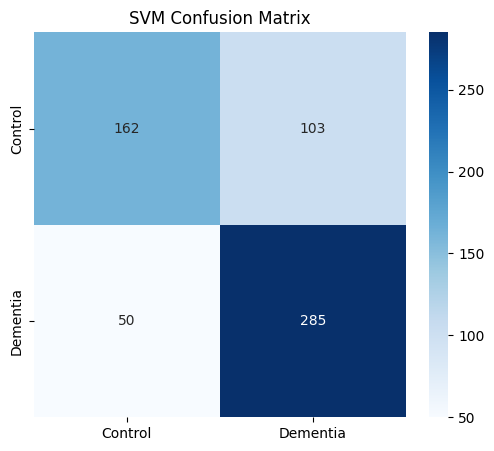

In [22]:
print("=" * 70)
print("SOLUSI: HYBRID MODEL (Wav2Vec2 Feature Extractor + SVM Classifier)")
print("=" * 70)

from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

def extract_embeddings(dataset, processor, model, device):
    print(f"Extracting features from {len(dataset)} samples...")
    embeddings = []
    labels = []

    model.eval()
    model.to(device)

    with torch.no_grad():
        for i in tqdm(range(len(dataset))):
            item = dataset[i]

            inputs = item["input_values"].unsqueeze(0).to(device)

            outputs = model(inputs, output_hidden_states=True)

            last_hidden_state = outputs.hidden_states[-1] # Shape: [1, Time, 768]
            pooled_output = torch.mean(last_hidden_state, dim=1).cpu().numpy()[0]

            embeddings.append(pooled_output)
            labels.append(item["labels"].item())

    return np.array(embeddings), np.array(labels)

print("Preparing Data...")
hybrid_ds = AlzheimerDatasetSliding(
    augmented_dataset,
    processor,
    segment_length=5,
    overlap=0.2,  # Overlap dikit biar data gak terlalu miskin
    max_samples=3000 # Batas aman
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if 'final_model' not in globals():
    final_config = Wav2Vec2Config.from_pretrained("facebook/wav2vec2-base", num_labels=2)
    final_model = Wav2Vec2ForSequenceClassification.from_pretrained("facebook/wav2vec2-base", config=final_config)

X, y = extract_embeddings(hybrid_ds, processor, final_model, device)

print(f"\nFeature Shape: {X.shape} (Samples, Features)")

print("\nTraining SVM Classifier...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=3.0, gamma='scale'))

    svm.fit(X_train, y_train)
    preds = svm.predict(X_val)

    acc = accuracy_score(y_val, preds)
    fold_accs.append(acc)
    print(f"Fold {fold+1}: SVM Accuracy = {acc:.4f}")

print(f"\n✅ Rata-rata Akurasi SVM: {np.mean(fold_accs):.4f}")
print("\nClassification Report (Contoh Fold Terakhir):")
print(classification_report(y_val, preds, target_names=["Control", "Dementia"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_val, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Control", "Dementia"], yticklabels=["Control", "Dementia"])
plt.title("SVM Confusion Matrix")
plt.show()